Dataset : CICIDS

Portion : Friday-WorkingHours-Afternoon-PortScan

File-name : Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv.zip



In [17]:
import pandas as pd

df = pd.read_csv("Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")
print(df.shape)
df.head()

(286467, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286467 entries, 0 to 286466
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             286467 non-null  int64  
 1    Flow Duration                286467 non-null  int64  
 2    Total Fwd Packets            286467 non-null  int64  
 3    Total Backward Packets       286467 non-null  int64  
 4   Total Length of Fwd Packets   286467 non-null  int64  
 5    Total Length of Bwd Packets  286467 non-null  int64  
 6    Fwd Packet Length Max        286467 non-null  int64  
 7    Fwd Packet Length Min        286467 non-null  int64  
 8    Fwd Packet Length Mean       286467 non-null  float64
 9    Fwd Packet Length Std        286467 non-null  float64
 10  Bwd Packet Length Max         286467 non-null  int64  
 11   Bwd Packet Length Min        286467 non-null  int64  
 12   Bwd Packet Length Mean       286467 non-nul

Data Status:

Rows (entries): 286467

Columns (features): 79

__

Integer columns: 50

Float columns: 28

Categorical (Label): 1

In [19]:
df.columns = df.columns.str.strip()

**ETL (Extract, Transform, Load)**

In [20]:

columns = [
    " Destination Port",
    " Flow Duration",
    " Total Fwd Packets",
    " Total Backward Packets",
    " Total Length of Fwd Packets",
    " Total Length of Bwd Packets",
    " Flow Bytes/s",
    " Flow Packets/s",
    " Packet Length Mean",
    " Packet Length Std",
    " SYN Flag Count",
    " ACK Flag Count",
    " Down/Up Ratio",
    " Average Packet Size",
    " Label"
]

In [21]:
df = df[[col.strip() for col in columns]].copy()

# Drop rows with nulls
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Shape after cleaning: {df.shape}")
print(df['Label'].value_counts())

Shape after cleaning: (286452, 15)
Label
PortScan    158930
BENIGN      127522
Name: count, dtype: int64


Synthesize timestamps (time dimension source)

In [22]:
import numpy as np

In [23]:
# The dataset has no real timestamps — we synthesize them.
# Friday afternoon PortScan: 13:00 to 17:00 window (4 hours = 14400 seconds)
# Distribute 286k flows uniformly across this window.

base_time = pd.Timestamp("2017-07-07 13:00:00")
total_seconds = 4 * 60 * 60  # 14400 seconds

np.random.seed(42)
offsets = np.sort(np.random.uniform(0, total_seconds, size=len(df)))
df['timestamp'] = base_time + pd.to_timedelta(offsets, unit='s')

# Derive time components
df['hour']        = df['timestamp'].dt.hour
df['minute']      = df['timestamp'].dt.minute
df['second']      = df['timestamp'].dt.second
df['time_bucket'] = df['timestamp'].dt.floor('5min')   # 5-minute buckets
df['period']      = pd.cut(
    df['hour'],
    bins=[12, 14, 16, 18],
    labels=['early_afternoon', 'mid_afternoon', 'late_afternoon'],
    right=False
)

print(df[['timestamp','hour','minute','time_bucket','period']].head(5))

                      timestamp  hour  minute         time_bucket  \
0 2017-07-07 13:00:00.033093829    13       0 2017-07-07 13:00:00   
1 2017-07-07 13:00:00.068811972    13       0 2017-07-07 13:00:00   
2 2017-07-07 13:00:00.079728131    13       0 2017-07-07 13:00:00   
3 2017-07-07 13:00:00.080526888    13       0 2017-07-07 13:00:00   
4 2017-07-07 13:00:00.094636765    13       0 2017-07-07 13:00:00   

            period  
0  early_afternoon  
1  early_afternoon  
2  early_afternoon  
3  early_afternoon  
4  early_afternoon  


Fact Table: network_flows

Field	Type

flow_duration    	measure

bytes_per_sec   	measure

packets_per_sec 	measure

avg_packet_size  	measure

packet_length_mean	measure

syn_flag_count	measure

is_attack	measure



Diminsion table and Surrogate Keys

In [24]:
dim_time = df[['timestamp','hour','minute','second','time_bucket','period']].drop_duplicates()
dim_time = dim_time.sort_values('timestamp').reset_index(drop=True)
dim_time['time_id'] = dim_time.index + 1   # surrogate key

# Map time_id back to main df for the fact table FK
df = df.merge(
    dim_time[['timestamp','time_id']],
    on='timestamp',
    how='left'
)

print(f"dim_time shape: {dim_time.shape}")
print(dim_time[['time_id','hour','minute','time_bucket','period']].head(8))

dim_time shape: (286452, 7)
   time_id  hour  minute         time_bucket           period
0        1    13       0 2017-07-07 13:00:00  early_afternoon
1        2    13       0 2017-07-07 13:00:00  early_afternoon
2        3    13       0 2017-07-07 13:00:00  early_afternoon
3        4    13       0 2017-07-07 13:00:00  early_afternoon
4        5    13       0 2017-07-07 13:00:00  early_afternoon
5        6    13       0 2017-07-07 13:00:00  early_afternoon
6        7    13       0 2017-07-07 13:00:00  early_afternoon
7        8    13       0 2017-07-07 13:00:00  early_afternoon


Dim_port

In [25]:
def classify_port(port):
    """Categorize destination port into service bucket."""
    port = int(port)
    well_known = {
        80: 'HTTP', 443: 'HTTPS', 22: 'SSH', 21: 'FTP',
        25: 'SMTP', 53: 'DNS', 110: 'POP3', 143: 'IMAP',
        3306: 'MySQL', 3389: 'RDP', 8080: 'HTTP-Alt'
    }
    if port in well_known:
        return well_known[port]
    elif port == 0:
        return 'Unknown'
    elif port < 1024:
        return 'Well-Known'
    elif port < 49152:
        return 'Registered'
    else:
        return 'Dynamic/Private'

dim_port = (
    df[['Destination Port']]
    .drop_duplicates()
    .sort_values('Destination Port')
    .reset_index(drop=True)
)
dim_port['port_id']      = dim_port.index + 1
dim_port['service_type'] = dim_port['Destination Port'].apply(classify_port)
dim_port['is_privileged'] = (dim_port['Destination Port'] < 1024).astype(int)

# Map port_id back to main df
df = df.merge(
    dim_port[['Destination Port','port_id']],
    on='Destination Port',
    how='left'
)

print(f"dim_port shape: {dim_port.shape}")
print(dim_port.groupby('service_type').size().sort_values(ascending=False))

dim_port shape: (14493, 4)
service_type
Registered         7720
Dynamic/Private    6613
Well-Known          148
HTTP                  1
HTTP-Alt              1
DNS                   1
FTP                   1
IMAP                  1
HTTPS                 1
POP3                  1
MySQL                 1
RDP                   1
SMTP                  1
SSH                   1
Unknown               1
dtype: int64


In [26]:
def classify_flow(row):
    """Classify flow type based on flags and label."""
    if row['Label'] != 'BENIGN':
        return 'attack'
    elif row['SYN Flag Count'] > 0 and row['ACK Flag Count'] == 0:
        return 'syn_only'
    elif row['ACK Flag Count'] > 0:
        return 'established'
    else:
        return 'other'

dim_traffic_raw = df[['Label']].copy()
dim_traffic_raw['flow_type'] = df.apply(classify_flow, axis=1)
dim_traffic_raw['is_attack']  = (df['Label'] != 'BENIGN').astype(int)
dim_traffic_raw['direction']  = df.apply(
    lambda r: 'outbound_heavy' if r['Total Fwd Packets'] > r['Total Backward Packets'] else 'inbound_heavy',
    axis=1
)

dim_traffic = dim_traffic_raw.drop_duplicates().reset_index(drop=True)
dim_traffic['traffic_id'] = dim_traffic.index + 1

# Map traffic_id back to main df
df = df.merge(
    dim_traffic,
    on=['Label'],
    how='left'
)

print(f"dim_traffic shape: {dim_traffic.shape}")
print(dim_traffic)

dim_traffic shape: (6, 5)
      Label    flow_type  is_attack       direction  traffic_id
0    BENIGN        other          0   inbound_heavy           1
1    BENIGN  established          0   inbound_heavy           2
2    BENIGN        other          0  outbound_heavy           3
3    BENIGN  established          0  outbound_heavy           4
4  PortScan       attack          1  outbound_heavy           5
5  PortScan       attack          1   inbound_heavy           6


In [27]:
fact_flows = df[[
    # Surrogate foreign keys
    'time_id',
    'port_id',
    'traffic_id',
    # Measures
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Packet Length Mean',
    'Packet Length Std',
    'SYN Flag Count',
    'ACK Flag Count',
    'Down/Up Ratio',
    'Average Packet Size',
    # Degenerate dimension (keep label for easy filtering)
    'Label'
]].copy()

fact_flows.reset_index(drop=True, inplace=True)
fact_flows.index.name = 'flow_id'
fact_flows = fact_flows.reset_index()
fact_flows['flow_id'] = fact_flows['flow_id'] + 1  # 1-based PK

print(f"fact_flows shape: {fact_flows.shape}")
print(fact_flows.dtypes)
print(fact_flows.head(3))

fact_flows shape: (827948, 18)
flow_id                          int64
time_id                          int64
port_id                          int64
traffic_id                       int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
Total Length of Bwd Packets      int64
Flow Bytes/s                   float64
Flow Packets/s                 float64
Packet Length Mean             float64
Packet Length Std              float64
SYN Flag Count                   int64
ACK Flag Count                   int64
Down/Up Ratio                    int64
Average Packet Size            float64
Label                           object
dtype: object
   flow_id  time_id  port_id  traffic_id  Flow Duration  Total Fwd Packets  \
0        1        1       13           1        1266342                 41   
1        2        1       13           2        1266342                 41   
2        3        1

In [28]:
import duckdb

# In-memory DuckDB instance (fast, no setup needed)
con = duckdb.connect(database=':memory:')

# Register all tables
con.register('dim_time',    dim_time)
con.register('dim_port',    dim_port)
con.register('dim_traffic', dim_traffic)
con.register('fact_flows',  fact_flows)

# Verify with a quick sanity query
result = con.execute("""
    SELECT
        dt.period,
        dp.service_type,
        dtr.is_attack,
        COUNT(*)            AS flow_count,
        ROUND(AVG(f."Flow Bytes/s"), 2)  AS avg_bytes_per_sec,
        ROUND(AVG(f."Average Packet Size"), 2) AS avg_pkt_size
    FROM fact_flows f
    JOIN dim_time    dt  ON f.time_id    = dt.time_id
    JOIN dim_port    dp  ON f.port_id    = dp.port_id
    JOIN dim_traffic dtr ON f.traffic_id = dtr.traffic_id
    GROUP BY dt.period, dp.service_type, dtr.is_attack
    ORDER BY flow_count DESC
    LIMIT 10
""").df()

print("=== Star Schema sanity check ===")
print(result.to_string(index=False))

=== Star Schema sanity check ===
         period    service_type  is_attack  flow_count  avg_bytes_per_sec  avg_pkt_size
  mid_afternoon      Registered          1      194642                inf          3.95
early_afternoon             DNS          0      133156          503837.13         91.16
 late_afternoon             DNS          0       64960          474941.64         89.98
 late_afternoon      Registered          1       55026                inf          4.14
early_afternoon           HTTPS          0       52696                inf        236.79
early_afternoon            HTTP          0       43556                inf        138.42
 late_afternoon           HTTPS          0       38500                inf        232.56
  mid_afternoon             DNS          0       36224          525184.86         91.76
  mid_afternoon      Well-Known          1       35896                inf          3.92
early_afternoon Dynamic/Private          0       26568                inf         30.51

In [29]:
import os
import duckdb

os.makedirs("warehouse", exist_ok=True)

dim_time.to_csv("warehouse/dim_time.csv",    index=False)
dim_port.to_csv("warehouse/dim_port.csv",    index=False)
dim_traffic.to_csv("warehouse/dim_traffic.csv", index=False)
fact_flows.to_csv("warehouse/fact_flows.csv",   index=False)

# Also persist DuckDB to file for use in later phases
con_disk = duckdb.connect("warehouse/ids_warehouse.duckdb")
con_disk.execute("CREATE OR REPLACE TABLE dim_time    AS SELECT * FROM dim_time")
con_disk.execute("CREATE OR REPLACE TABLE dim_port    AS SELECT * FROM dim_port")
con_disk.execute("CREATE OR REPLACE TABLE dim_traffic AS SELECT * FROM dim_traffic")
con_disk.execute("CREATE OR REPLACE TABLE fact_flows  AS SELECT * FROM fact_flows")
con_disk.close()

print("All tables saved to ./warehouse/")

All tables saved to ./warehouse/


In [30]:
import os

files = [
    "warehouse/dim_time.csv",
    "warehouse/dim_port.csv",
    "warehouse/dim_traffic.csv",
    "warehouse/fact_flows.csv",
    "warehouse/ids_warehouse.duckdb"
]

for f in files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"{f:45s} → {size_mb:.2f} MB")

warehouse/dim_time.csv                        → 21.86 MB
warehouse/dim_port.csv                        → 0.36 MB
warehouse/dim_traffic.csv                     → 0.00 MB
warehouse/fact_flows.csv                      → 74.51 MB
warehouse/ids_warehouse.duckdb                → 40.26 MB


Verify

In [32]:
import duckdb
con = duckdb.connect("warehouse/ids_warehouse.duckdb")

# Verify everything is intact
con.execute("SHOW TABLES").df()

,name
0,dim_port
1,dim_time
2,dim_traffic
3,fact_flows


SLICE

In [35]:
# SLICE: only PortScan attack flows
slice_portscan = con.execute("""
    SELECT
        f.flow_id,
        dt.hour,
        dt.time_bucket,
        dp."Destination Port",
        dp.service_type,
        f."Flow Bytes/s",
        f."Flow Packets/s",
        f."Average Packet Size",
        f."SYN Flag Count",
        f."ACK Flag Count"
    FROM fact_flows f
    JOIN dim_time    dt  ON f.time_id  = dt.time_id
    JOIN dim_port    dp  ON f.port_id  = dp.port_id
    JOIN dim_traffic dtr ON f.traffic_id = dtr.traffic_id
    WHERE dtr.is_attack = 1
    ORDER BY dt.hour, dt.time_bucket
""").df()

print(f"SLICE result → {slice_portscan.shape[0]:,} attack flows (out of 286k total)")
print(slice_portscan.head(5))

SLICE result → 317,860 attack flows (out of 286k total)
   flow_id  hour         time_bucket  Destination Port service_type  \
0     5853    13 2017-07-07 13:00:00                80         HTTP   
1     5854    13 2017-07-07 13:00:00                80         HTTP   
2     5867    13 2017-07-07 13:00:00                80         HTTP   
3     5868    13 2017-07-07 13:00:00                80         HTTP   
4     5869    13 2017-07-07 13:00:00                80         HTTP   

   Flow Bytes/s  Flow Packets/s  Average Packet Size  SYN Flag Count  \
0    421.624203        2.190773           192.454545               0   
1    421.624203        2.190773           192.454545               0   
2      0.000000    28571.428570             0.000000               0   
3      0.000000    28571.428570             0.000000               0   
4    421.359692        2.189398           192.454545               0   

   ACK Flag Count  
0               0  
1               0  
2               1  
3   

In [36]:
# DICE: PortScan attacks + afternoon hours (14–16) + privileged ports (<1024)
dice_result = con.execute("""
    SELECT
        dt.hour,
        dt.period,
        dp.service_type,
        dp.is_privileged,
        dtr.flow_type,
        COUNT(*)                              AS flow_count,
        ROUND(AVG(f."Flow Bytes/s"), 2)       AS avg_bytes_per_sec,
        ROUND(AVG(f."SYN Flag Count"), 3)     AS avg_syn_flags,
        ROUND(AVG(f."Average Packet Size"), 2) AS avg_pkt_size
    FROM fact_flows f
    JOIN dim_time    dt  ON f.time_id    = dt.time_id
    JOIN dim_port    dp  ON f.port_id    = dp.port_id
    JOIN dim_traffic dtr ON f.traffic_id = dtr.traffic_id
    WHERE
        dtr.is_attack    = 1          -- dimension 1: only attacks
        AND dt.hour BETWEEN 14 AND 16 -- dimension 2: mid-afternoon
        AND dp.is_privileged = 1      -- dimension 3: privileged ports only
    GROUP BY dt.hour, dt.period, dp.service_type, dp.is_privileged, dtr.flow_type
    ORDER BY flow_count DESC
""").df()

print("DICE result → PortScan ∩ Hour[14-16] ∩ PrivilegedPorts")
print(dice_result.to_string(index=False))

DICE result → PortScan ∩ Hour[14-16] ∩ PrivilegedPorts
 hour         period service_type  is_privileged flow_type  flow_count  avg_bytes_per_sec  avg_syn_flags  avg_pkt_size
   15  mid_afternoon   Well-Known              1    attack       20048                inf            0.0          3.08
   14  mid_afternoon   Well-Known              1    attack       15848                inf            0.0          4.99
   16 late_afternoon   Well-Known              1    attack       10278          203718.37            0.0          4.35
   16 late_afternoon         HTTP              1    attack         258          834505.77            0.0        506.66
   15  mid_afternoon         HTTP              1    attack         140             873.31            0.0          0.23
   15  mid_afternoon        HTTPS              1    attack         140          155983.77            0.0          3.11
   15  mid_afternoon         POP3              1    attack         140          167908.39            0.0        

In [37]:
# Hierarchy: individual flow → 5-min bucket → hour → period
# We show all 3 levels explicitly

# Level 1: per 5-minute bucket (finest)
rollup_5min = con.execute("""
    SELECT
        dt.time_bucket,
        dtr.is_attack,
        COUNT(*)                         AS flow_count,
        ROUND(SUM(f."Flow Bytes/s"), 2)  AS total_bytes_per_sec,
        ROUND(AVG(f."Packet Length Mean"), 2) AS avg_pkt_len
    FROM fact_flows f
    JOIN dim_time    dt  ON f.time_id    = dt.time_id
    JOIN dim_traffic dtr ON f.traffic_id = dtr.traffic_id
    GROUP BY dt.time_bucket, dtr.is_attack
    ORDER BY dt.time_bucket
""").df()

# Level 2: roll up to hour
rollup_hour = con.execute("""
    SELECT
        dt.hour,
        dtr.is_attack,
        COUNT(*)                         AS flow_count,
        ROUND(SUM(f."Flow Bytes/s"), 2)  AS total_bytes_per_sec,
        ROUND(AVG(f."Packet Length Mean"), 2) AS avg_pkt_len
    FROM fact_flows f
    JOIN dim_time    dt  ON f.time_id    = dt.time_id
    JOIN dim_traffic dtr ON f.traffic_id = dtr.traffic_id
    GROUP BY dt.hour, dtr.is_attack
    ORDER BY dt.hour
""").df()

# Level 3: roll up to period (coarsest)
rollup_period = con.execute("""
    SELECT
        dt.period,
        dtr.is_attack,
        COUNT(*)                         AS flow_count,
        ROUND(SUM(f."Flow Bytes/s"), 2)  AS total_bytes_per_sec,
        ROUND(AVG(f."Packet Length Mean"), 2) AS avg_pkt_len
    FROM fact_flows f
    JOIN dim_time    dt  ON f.time_id    = dt.time_id
    JOIN dim_traffic dtr ON f.traffic_id = dtr.traffic_id
    GROUP BY dt.period, dtr.is_attack
    ORDER BY dt.period
""").df()

print("ROLL-UP Level 1 → per 5-min bucket")
print(rollup_5min.head(8).to_string(index=False))

print("\nROLL-UP Level 2 → per hour")
print(rollup_hour.to_string(index=False))

print("\nROLL-UP Level 3 → per period (coarsest)")
print(rollup_period.to_string(index=False))

ROLL-UP Level 1 → per 5-min bucket
        time_bucket  is_attack  flow_count  total_bytes_per_sec  avg_pkt_len
2017-07-07 13:00:00          0       23644                  inf        96.37
2017-07-07 13:00:00          1          14         2.529320e+03        75.60
2017-07-07 13:05:00          0       23312                  inf       102.61
2017-07-07 13:10:00          0       23972                  inf       100.74
2017-07-07 13:15:00          0       24620                  inf       113.19
2017-07-07 13:20:00          0       23940         4.539220e+10        95.90
2017-07-07 13:25:00          0       23584                  inf        96.43
2017-07-07 13:30:00          0       22636                  inf       102.45

ROLL-UP Level 2 → per hour
 hour  is_attack  flow_count  total_bytes_per_sec  avg_pkt_len
   13          0      284656                  inf       101.94
   13          1         744         157922708.75        91.90
   14          0       67424                  inf      

In [38]:
# Start from period level, drill into a suspicious period → then to hour → then to bucket

# Step 1: which period has most attacks? (coarse view)
drill_step1 = con.execute("""
    SELECT dt.period, COUNT(*) AS attack_flows
    FROM fact_flows f
    JOIN dim_time    dt  ON f.time_id    = dt.time_id
    JOIN dim_traffic dtr ON f.traffic_id = dtr.traffic_id
    WHERE dtr.is_attack = 1
    GROUP BY dt.period
    ORDER BY attack_flows DESC
""").df()
print("Drill-down Step 1 → by period")
print(drill_step1.to_string(index=False))

# Step 2: drill into the busiest period → break by hour
busiest_period = drill_step1.iloc[0]['period']
drill_step2 = con.execute(f"""
    SELECT dt.hour, COUNT(*) AS attack_flows,
           ROUND(AVG(f."Flow Packets/s"), 2) AS avg_pkt_per_sec
    FROM fact_flows f
    JOIN dim_time    dt  ON f.time_id    = dt.time_id
    JOIN dim_traffic dtr ON f.traffic_id = dtr.traffic_id
    WHERE dtr.is_attack = 1 AND dt.period = '{busiest_period}'
    GROUP BY dt.hour
    ORDER BY dt.hour
""").df()
print(f"\nDrill-down Step 2 → inside '{busiest_period}', by hour")
print(drill_step2.to_string(index=False))

# Step 3: drill into the busiest hour → break by 5-min bucket
busiest_hour = drill_step2.sort_values('attack_flows', ascending=False).iloc[0]['hour']
drill_step3 = con.execute(f"""
    SELECT dt.time_bucket, COUNT(*) AS attack_flows,
           ROUND(AVG(f."SYN Flag Count"), 3) AS avg_syn,
           ROUND(AVG(f."Flow Bytes/s"), 2)   AS avg_bytes_sec
    FROM fact_flows f
    JOIN dim_time    dt  ON f.time_id    = dt.time_id
    JOIN dim_traffic dtr ON f.traffic_id = dtr.traffic_id
    WHERE dtr.is_attack = 1 AND dt.hour = {busiest_hour}
    GROUP BY dt.time_bucket
    ORDER BY dt.time_bucket
""").df()
print(f"\nDrill-down Step 3 → inside hour {busiest_hour}, by 5-min bucket")
print(drill_step3.to_string(index=False))

Drill-down Step 1 → by period
         period  attack_flows
  mid_afternoon        246942
 late_afternoon         70174
early_afternoon           744

Drill-down Step 2 → inside 'mid_afternoon', by hour
 hour  attack_flows  avg_pkt_per_sec
   14        109006              inf
   15        137936              inf

Drill-down Step 3 → inside hour 15.0, by 5-min bucket
        time_bucket  attack_flows  avg_syn  avg_bytes_sec
2017-07-07 15:00:00          9840      0.0            inf
2017-07-07 15:05:00         11038      0.0            inf
2017-07-07 15:10:00         11828      0.0            inf
2017-07-07 15:15:00         11362      0.0            inf
2017-07-07 15:20:00         11598      0.0            inf
2017-07-07 15:25:00         11972      0.0            inf
2017-07-07 15:30:00         11862      0.0            inf
2017-07-07 15:35:00         11920      0.0            inf
2017-07-07 15:40:00         11456      0.0            inf
2017-07-07 15:45:00         11726      0.0         

In [39]:
# Pivot 1: rows = hour, columns = attack/benign, values = flow count
pivot_count = con.execute("""
    SELECT
        dt.hour,
        COUNT(*) FILTER (WHERE dtr.is_attack = 0) AS benign_flows,
        COUNT(*) FILTER (WHERE dtr.is_attack = 1) AS attack_flows,
        COUNT(*)                                   AS total_flows,
        ROUND(
            100.0 * COUNT(*) FILTER (WHERE dtr.is_attack = 1) / COUNT(*), 2
        )                                          AS attack_pct
    FROM fact_flows f
    JOIN dim_time    dt  ON f.time_id    = dt.time_id
    JOIN dim_traffic dtr ON f.traffic_id = dtr.traffic_id
    GROUP BY dt.hour
    ORDER BY dt.hour
""").df()

print("PIVOT 1 → hour × label (flow count)")
print(pivot_count.to_string(index=False))

# Pivot 2: rows = service_type, columns = metric aggregates
pivot_metrics = con.execute("""
    SELECT
        dp.service_type,
        COUNT(*)                                    AS flow_count,
        ROUND(AVG(f."Average Packet Size"), 2)      AS avg_pkt_size,
        ROUND(AVG(f."Flow Bytes/s"), 2)             AS avg_bytes_sec,
        ROUND(AVG(f."SYN Flag Count"), 3)           AS avg_syn,
        ROUND(AVG(f."Down/Up Ratio"), 3)            AS avg_downup_ratio
    FROM fact_flows f
    JOIN dim_port    dp  ON f.port_id    = dp.port_id
    JOIN dim_traffic dtr ON f.traffic_id = dtr.traffic_id
    WHERE dtr.is_attack = 1
    GROUP BY dp.service_type
    ORDER BY flow_count DESC
""").df()

print("\nPIVOT 2 → service type × metrics (attack flows only)")
print(pivot_metrics.to_string(index=False))

PIVOT 1 → hour × label (flow count)
 hour  benign_flows  attack_flows  total_flows  attack_pct
   13        284656           744       285400        0.26
   14         67424        109006       176430       61.78
   15         11556        137936       149492       92.27
   16        146452         70174       216626       32.39

PIVOT 2 → service type × metrics (attack flows only)
   service_type  flow_count  avg_pkt_size  avg_bytes_sec  avg_syn  avg_downup_ratio
     Registered      249668          3.99            inf      0.0             1.000
     Well-Known       46274          4.02            inf      0.0             0.984
Dynamic/Private       17484          3.99            inf      0.0             1.000
           HTTP         746        277.84      470713.60      0.0             0.314
            FTP         488          2.21        8068.89      0.0             0.000
            SSH         486          2.67        8401.83      0.0             0.000
          HTTPS         480

In [41]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        "Roll-up: flow count by hour",
        "Pivot: attack % by hour",
        "Dice: avg bytes/s by service type (attacks)",
        "Drill-down: attack flows by 5-min bucket"
    ]
)

# Plot 1: Roll-up by hour
for attack_val, name, color in [(0,'Benign','steelblue'), (1,'Attack','crimson')]:
    sub = rollup_hour[rollup_hour['is_attack'] == attack_val]
    fig.add_trace(go.Bar(x=sub['hour'], y=sub['flow_count'],
                         name=name, marker_color=color,
                         showlegend=True), row=1, col=1)

# Plot 2: Attack % by hour
fig.add_trace(go.Scatter(
    x=pivot_count['hour'], y=pivot_count['attack_pct'],
    mode='lines+markers', name='Attack %',
    line=dict(color='crimson', width=2),
    showlegend=False
), row=1, col=2)

# Plot 3: Avg bytes by service type (dice result)
fig.add_trace(go.Bar(
    x=pivot_metrics['service_type'],
    y=pivot_metrics['avg_bytes_sec'],
    marker_color='darkorange', name='Avg bytes/s',
    showlegend=False
), row=2, col=1)

# Plot 4: Drill-down 5-min bucket
fig.add_trace(go.Scatter(
    x=drill_step3['time_bucket'].astype(str),
    y=drill_step3['attack_flows'],
    mode='lines+markers', name='Attack flows',
    line=dict(color='purple', width=2),
    showlegend=False
), row=2, col=2)

fig.update_layout(
    height=700,
    title_text="OLAP Cube Operations Dashboard",
    barmode='group',
    template='plotly_white'
)
fig.show()

In [42]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

con = duckdb.connect("warehouse/ids_warehouse.duckdb")

# Load fact table joined with dimensions for ML
ml_df = con.execute("""
    SELECT
        f."Flow Duration",
        f."Total Fwd Packets",
        f."Total Backward Packets",
        f."Total Length of Fwd Packets",
        f."Total Length of Bwd Packets",
        f."Flow Bytes/s",
        f."Flow Packets/s",
        f."Packet Length Mean",
        f."Packet Length Std",
        f."SYN Flag Count",
        f."ACK Flag Count",
        f."Down/Up Ratio",
        f."Average Packet Size",
        dtr.is_attack,
        dt.hour,
        dt.time_bucket
    FROM fact_flows f
    JOIN dim_time    dt  ON f.time_id    = dt.time_id
    JOIN dim_traffic dtr ON f.traffic_id = dtr.traffic_id
""").df()

ml_df['time_bucket'] = pd.to_datetime(ml_df['time_bucket'])

FEATURES = [
    "Flow Duration", "Total Fwd Packets", "Total Backward Packets",
    "Total Length of Fwd Packets", "Total Length of Bwd Packets",
    "Flow Bytes/s", "Flow Packets/s", "Packet Length Mean",
    "Packet Length Std", "SYN Flag Count", "ACK Flag Count",
    "Down/Up Ratio", "Average Packet Size"
]

X = ml_df[FEATURES]
y = ml_df['is_attack']

print(f"Dataset shape : {ml_df.shape}")
print(f"Attack flows  : {y.sum():,}  ({100*y.mean():.1f}%)")
print(f"Benign flows  : {(1-y).sum():,}  ({100*(1-y.mean()):.1f}%)")

Dataset shape : (827948, 16)
Attack flows  : 317,860  (38.4%)
Benign flows  : 510,088  (61.6%)


=== Isolation Forest — Anomaly Detection ===
              precision    recall  f1-score   support

      Benign       0.58      0.85      0.69    510088
      Attack       0.01      0.00      0.01    317860

    accuracy                           0.53    827948
   macro avg       0.30      0.43      0.35    827948
weighted avg       0.36      0.53      0.43    827948



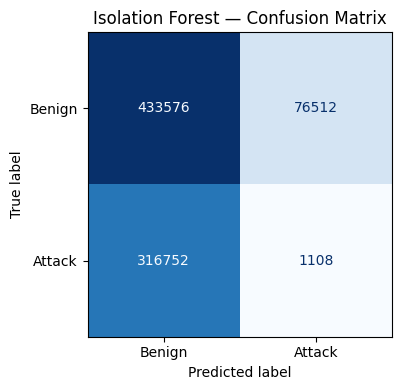

In [44]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np # Import numpy for np.inf and np.nan

# Handle infinite values in X before scaling
X = X.replace([np.inf, -np.inf], np.nan)
for col in X.columns:
    if X[col].isnull().any():
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train ONLY on benign flows — unsupervised anomaly detection
X_benign = X_scaled[y == 0]

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.15,   # ~15% expected anomalies
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_benign)

# Predict on ALL flows: -1 = anomaly, 1 = normal
raw_pred = iso_forest.predict(X_scaled)

# Convert to binary: anomaly=1, normal=0
ml_df['iso_pred'] = (raw_pred == -1).astype(int)

# Anomaly scores (more negative = more anomalous)
ml_df['anomaly_score'] = iso_forest.score_samples(X_scaled)

print("=== Isolation Forest — Anomaly Detection ===")
print(classification_report(y, ml_df['iso_pred'],
      target_names=['Benign', 'Attack']))

# Confusion matrix
cm = confusion_matrix(y, ml_df['iso_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Benign', 'Attack'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Isolation Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

=== Random Forest — Supervised Classification ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    102018
      Attack       1.00      1.00      1.00     63572

    accuracy                           1.00    165590
   macro avg       1.00      1.00      1.00    165590
weighted avg       1.00      1.00      1.00    165590

ROC-AUC Score : 1.0000


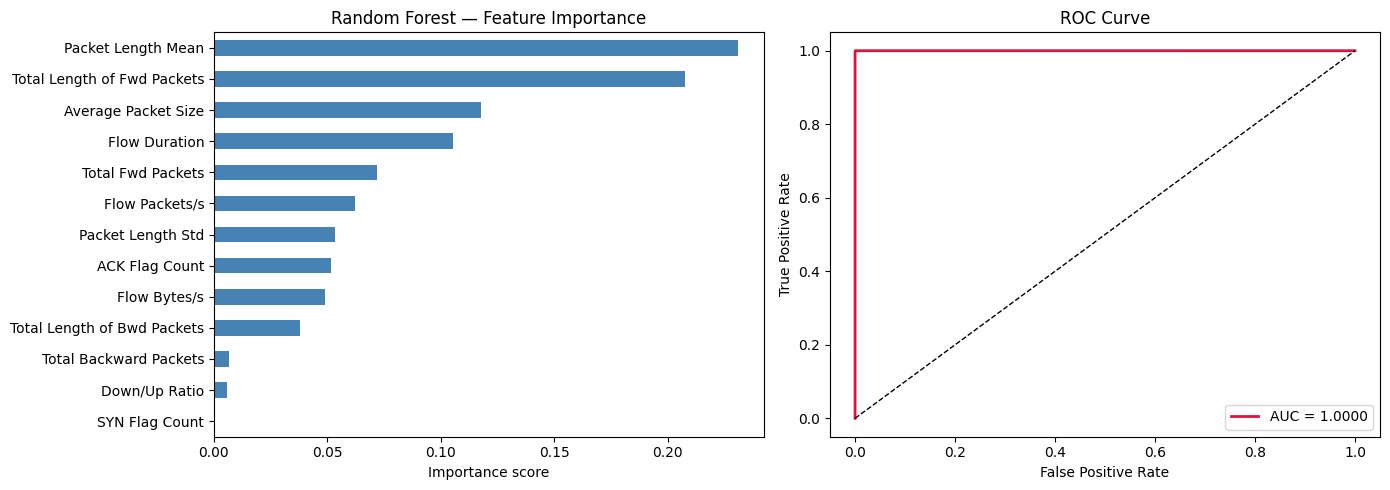

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest — Supervised Classification ===")
print(classification_report(y_test, y_pred,
      target_names=['Benign', 'Attack']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")

# Feature importance plot
importances = pd.Series(rf.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
importances.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Random Forest — Feature Importance")
axes[0].set_xlabel("Importance score")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='crimson', lw=2,
             label=f"AUC = {roc_auc_score(y_test, y_proba):.4f}")
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

Time series length : 47 buckets
time_bucket
2017-07-07 13:00:00     14
2017-07-07 13:05:00      0
2017-07-07 13:10:00      0
2017-07-07 13:15:00      0
2017-07-07 13:20:00      0
2017-07-07 13:25:00      0
2017-07-07 13:30:00    210
2017-07-07 13:35:00    244
Freq: 5min, Name: attack_count, dtype: int64

=== ARIMA Model Summary ===
                               SARIMAX Results                                
Dep. Variable:           attack_count   No. Observations:                   35
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -300.109
Date:                Mon, 06 Apr 2026   AIC                            610.217
Time:                        04:19:32   BIC                            617.849
Sample:                    07-07-2017   HQIC                           612.820
                         - 07-07-2017                                         
Covariance Type:                  opg                                         

MAE  : 5102.08 flows per 5-min bu

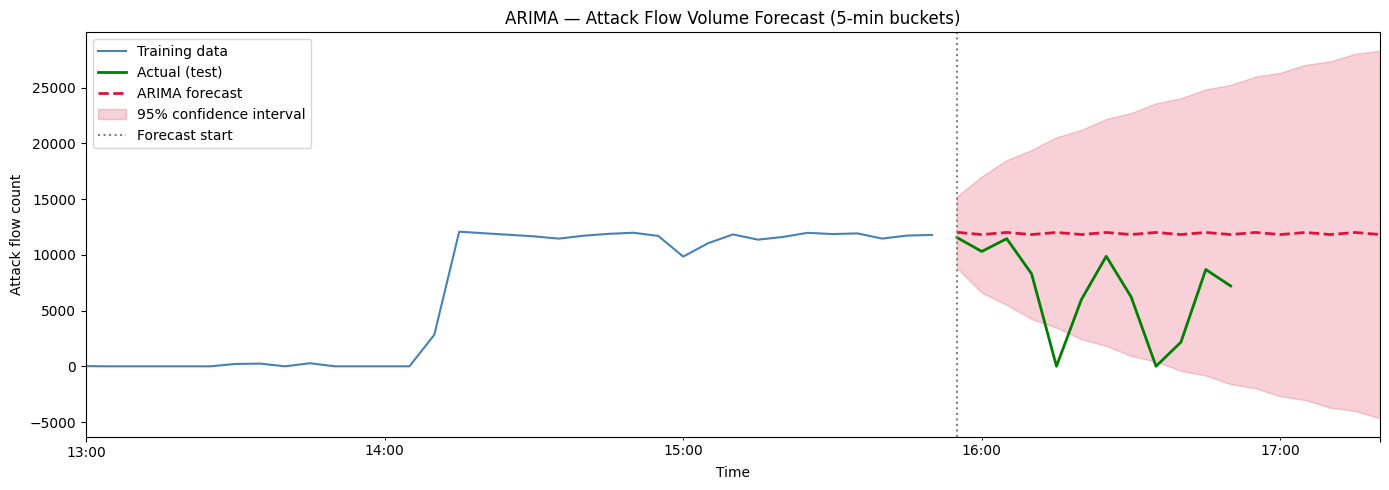

In [46]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Build time series: attack flow count per 5-minute bucket
ts = (
    ml_df[ml_df['is_attack'] == 1]
    .groupby('time_bucket')
    .size()
    .rename('attack_count')
    .asfreq('5min', fill_value=0)
)

print(f"Time series length : {len(ts)} buckets")
print(ts.head(8))

# Train/test split — last 12 buckets (60 min) as test
train_size = len(ts) - 12
train_ts   = ts.iloc[:train_size]
test_ts    = ts.iloc[train_size:]

# Fit ARIMA(2,1,2) — good general starting point for network traffic
model = ARIMA(train_ts, order=(2, 1, 2))
fitted = model.fit()

print("\n=== ARIMA Model Summary ===")
print(fitted.summary().tables[0])

# Forecast for the test window + 6 more steps (30 min ahead)
forecast_steps = len(test_ts) + 6
forecast = fitted.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci   = forecast.conf_int()

# Metrics on test window
mae  = mean_absolute_error(test_ts, forecast_mean[:len(test_ts)])
rmse = np.sqrt(mean_squared_error(test_ts, forecast_mean[:len(test_ts)]))
print(f"\nMAE  : {mae:.2f} flows per 5-min bucket")
print(f"RMSE : {rmse:.2f} flows per 5-min bucket")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
train_ts.plot(ax=ax, label='Training data', color='steelblue', lw=1.5)
test_ts.plot(ax=ax, label='Actual (test)', color='green', lw=2)
forecast_mean.plot(ax=ax, label='ARIMA forecast', color='crimson',
                   lw=2, linestyle='--')
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                alpha=0.2, color='crimson', label='95% confidence interval')
ax.axvline(x=test_ts.index[0], color='gray', linestyle=':', lw=1.5,
           label='Forecast start')
ax.set_title("ARIMA — Attack Flow Volume Forecast (5-min buckets)")
ax.set_xlabel("Time")
ax.set_ylabel("Attack flow count")
ax.legend()
plt.tight_layout()
plt.show()

Total rules found   : 140
Rules predicting ATTACK: 43

=== Top 10 Port Scan Signatures (by lift) ===
                             antecedents              consequents  support  confidence     lift
(short_duration, low_ACK, small_packets)                 (ATTACK)  0.37506    0.999733 2.635455
 (low_ACK, small_packets, high_pkt_rate)                 (ATTACK)  0.36010    0.999722 2.635426
               (short_duration, low_ACK)  (high_pkt_rate, ATTACK)  0.36010    0.908518 2.522959
                (low_ACK, small_packets)  (high_pkt_rate, ATTACK)  0.36010    0.903593 2.509284
                (low_ACK, small_packets) (short_duration, ATTACK)  0.37506    0.941132 2.509284
                (low_ACK, small_packets)                 (ATTACK)  0.37888    0.950718 2.506242
               (short_duration, low_ACK)  (small_packets, ATTACK)  0.37506    0.946261 2.496467
               (short_duration, low_ACK)                 (ATTACK)  0.37506    0.946261 2.494493
(short_duration, low_ACK, high_pkt_

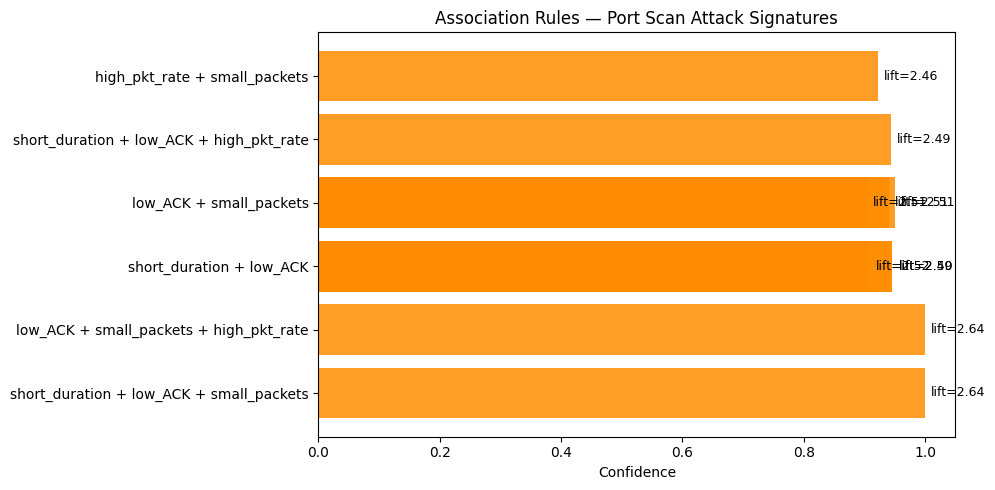

In [54]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Step 1: Discretize numeric features into meaningful binary flags
def discretize(df):
    d = pd.DataFrame()
    d['high_SYN']        = (df['SYN Flag Count'] > 0).astype(bool)
    d['low_ACK']         = (df['ACK Flag Count'] == 0).astype(bool)
    d['high_pkt_rate']   = (df['Flow Packets/s'] > df['Flow Packets/s'].median()).astype(bool)
    d['small_packets']   = (df['Packet Length Mean'] < df['Packet Length Mean'].median()).astype(bool)
    d['short_duration']  = (df['Flow Duration'] < df['Flow Duration'].median()).astype(bool)
    d['low_bytes']       = (df['Flow Bytes/s'] < df['Flow Bytes/s'].median()).astype(bool)
    d['high_fwd_pkts']   = (df['Total Fwd Packets'] > df['Total Fwd Packets'].median()).astype(bool)
    d['ATTACK']          = (ml_df['is_attack'] == 1)
    return d

binary_df = discretize(ml_df)

# Step 2: Sample for performance (Apriori is memory-heavy on 286k rows)
sample_df = binary_df.sample(n=50000, random_state=42)

# Step 3: Run Apriori
frequent_itemsets = apriori(
    sample_df,
    min_support=0.1,
    use_colnames=True,
    max_len=4
)

# Step 4: Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.7
)

# Step 5: Filter rules where consequent is ATTACK
attack_rules = rules[
    rules['consequents'].apply(lambda x: 'ATTACK' in x)
].sort_values('lift', ascending=False)

print(f"Total rules found   : {len(rules)}")
print(f"Rules predicting ATTACK: {len(attack_rules)}")
print("\n=== Top 10 Port Scan Signatures (by lift) ===")

display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(attack_rules[display_cols].head(10).to_string(index=False))

# Visualize top rules
top10 = attack_rules.head(10).copy()
top10['rule'] = top10['antecedents'].apply(
    lambda x: ' + '.join(list(x))
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10['rule'], top10['confidence'],
               color='darkorange', alpha=0.85)
ax.set_xlabel("Confidence")
ax.set_title("Association Rules — Port Scan Attack Signatures")
ax.set_xlim(0, 1.05)
for bar, lift in zip(bars, top10['lift']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"lift={lift:.2f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [53]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

print("=" * 55)
print("        ML MODEL SUMMARY")
print("=" * 55)

iso_acc = (ml_df['iso_pred'] == y).mean()
rf_acc  = (rf.predict(X_test) == y_test).mean()

summary = pd.DataFrame({
    'Model'     : ['Isolation Forest', 'Random Forest', 'ARIMA', 'Apriori'],
    'Type'      : ['Unsupervised', 'Supervised', 'Time-Series', 'Pattern Mining'],
    'Task'      : [
        'Anomaly detection',
        'Attack classification',
        'Traffic forecasting',
        'Signature discovery'
    ],
    'Key Metric': [
        f"Accuracy: {iso_acc:.3f}",
        f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}",
        f"RMSE: {rmse:.2f} flows/bucket",
        f"{len(attack_rules)} attack rules found"
    ]
})

print(summary.to_string(index=False))

        ML MODEL SUMMARY
           Model           Type                  Task                 Key Metric
Isolation Forest   Unsupervised     Anomaly detection            Accuracy: 0.525
   Random Forest     Supervised Attack classification            ROC-AUC: 1.0000
           ARIMA    Time-Series   Traffic forecasting RMSE: 6447.17 flows/bucket
         Apriori Pattern Mining   Signature discovery      43 attack rules found


In [55]:
import duckdb
import pandas as pd
import numpy as np
import time
from datetime import datetime
from collections import deque
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, clear_output
import ipywidgets as widgets
import warnings
warnings.filterwarnings('ignore')

# Reconnect to warehouse
con = duckdb.connect("warehouse/ids_warehouse.duckdb")

# Load full dataset ordered by time for realistic replay
stream_df = con.execute("""
    SELECT
        f.flow_id,
        f."Flow Duration",
        f."Flow Bytes/s",
        f."Flow Packets/s",
        f."Packet Length Mean",
        f."Packet Length Std",
        f."SYN Flag Count",
        f."ACK Flag Count",
        f."Average Packet Size",
        f."Down/Up Ratio",
        f.Label,
        dtr.is_attack,
        dt.time_bucket,
        dt.hour,
        dt.minute,
        dp.service_type,
        dp.is_privileged
    FROM fact_flows f
    JOIN dim_time    dt  ON f.time_id    = dt.time_id
    JOIN dim_traffic dtr ON f.traffic_id = dtr.traffic_id
    JOIN dim_port    dp  ON f.port_id    = dp.port_id
    ORDER BY dt.time_bucket, f.flow_id
""").df()

stream_df['time_bucket'] = pd.to_datetime(stream_df['time_bucket'])

print(f"Total flows loaded for streaming : {len(stream_df):,}")
print(f"Time range : {stream_df['time_bucket'].min()} → {stream_df['time_bucket'].max()}")
print(stream_df[['flow_id','time_bucket','Label','is_attack']].head(5))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total flows loaded for streaming : 827,948
Time range : 2017-07-07 13:00:00 → 2017-07-07 16:55:00
   flow_id         time_bucket   Label  is_attack
0        1 2017-07-07 13:00:00  BENIGN          0
1        2 2017-07-07 13:00:00  BENIGN          0
2        3 2017-07-07 13:00:00  BENIGN          0
3        4 2017-07-07 13:00:00  BENIGN          0
4        5 2017-07-07 13:00:00  BENIGN          0


In [56]:
class StreamEngine:
    """
    Simulates real-time ingestion by replaying the dataset
    in chronological micro-batches (one batch = one 5-min bucket).
    Maintains running OLAP aggregates without reprocessing old data.
    """

    def __init__(self, df, batch_size=500):
        self.df            = df
        self.batch_size    = batch_size
        self.cursor        = 0                  # current position in stream
        self.total_flows   = 0
        self.total_attacks = 0
        self.total_benign  = 0

        # Rolling windows (last N batches) for live charts
        self.window_size      = 30
        self.flow_counts      = deque(maxlen=self.window_size)
        self.attack_counts    = deque(maxlen=self.window_size)
        self.benign_counts    = deque(maxlen=self.window_size)
        self.timestamps       = deque(maxlen=self.window_size)
        self.avg_bytes        = deque(maxlen=self.window_size)
        self.avg_pkt_size     = deque(maxlen=self.window_size)

        # Streaming OLAP cube — updated incrementally
        self.olap_hour   = {}   # hour → {attack, benign, bytes}
        self.olap_port   = {}   # service_type → count
        self.alert_log   = []   # high-severity events

    def next_batch(self):
        """Fetch next micro-batch from stream."""
        if self.cursor >= len(self.df):
            return None   # stream exhausted

        batch = self.df.iloc[self.cursor : self.cursor + self.batch_size]
        self.cursor += self.batch_size
        return batch

    def process_batch(self, batch):
        """
        Ingest one micro-batch:
        1. Update running counters
        2. Update streaming OLAP cube
        3. Detect anomalies (rule-based for real-time speed)
        4. Log alerts
        """
        n_flows   = len(batch)
        n_attacks = int(batch['is_attack'].sum())
        n_benign  = n_flows - n_attacks

        # ── Running totals ──────────────────────────────────────
        self.total_flows   += n_flows
        self.total_attacks += n_attacks
        self.total_benign  += n_benign

        # ── Rolling window metrics ───────────────────────────────
        ts = batch['time_bucket'].iloc[0]
        self.timestamps.append(ts)
        self.flow_counts.append(n_flows)
        self.attack_counts.append(n_attacks)
        self.benign_counts.append(n_benign)
        self.avg_bytes.append(batch['Flow Bytes/s'].mean())
        self.avg_pkt_size.append(batch['Average Packet Size'].mean())

        # ── Streaming OLAP cube update ───────────────────────────
        for hour, grp in batch.groupby('hour'):
            if hour not in self.olap_hour:
                self.olap_hour[hour] = {'attack': 0, 'benign': 0, 'bytes': 0.0}
            self.olap_hour[hour]['attack'] += int(grp['is_attack'].sum())
            self.olap_hour[hour]['benign'] += int((grp['is_attack'] == 0).sum())
            self.olap_hour[hour]['bytes']  += float(grp['Flow Bytes/s'].sum())

        for stype, grp in batch.groupby('service_type'):
            self.olap_port[stype] = self.olap_port.get(stype, 0) + len(grp)

        # ── Real-time anomaly detection (rule-based) ─────────────
        # Rule 1: SYN flood — high SYN, zero ACK
        syn_flood = batch[
            (batch['SYN Flag Count'] > 0) &
            (batch['ACK Flag Count'] == 0) &
            (batch['is_attack'] == 1)
        ]
        if len(syn_flood) > 50:
            self.alert_log.append({
                'time'    : ts,
                'type'    : 'SYN Flood',
                'severity': 'HIGH',
                'count'   : len(syn_flood)
            })

        # Rule 2: Port scan burst — many flows, tiny packets
        scan_burst = batch[
            (batch['Packet Length Mean'] < 50) &
            (batch['Flow Packets/s'] > batch['Flow Packets/s'].quantile(0.75)) &
            (batch['is_attack'] == 1)
        ]
        if len(scan_burst) > 30:
            self.alert_log.append({
                'time'    : ts,
                'type'    : 'Port Scan Burst',
                'severity': 'MEDIUM',
                'count'   : len(scan_burst)
            })

        # Rule 3: Attack ratio spike — >80% of batch is attack
        if n_flows > 100 and (n_attacks / n_flows) > 0.8:
            self.alert_log.append({
                'time'    : ts,
                'type'    : 'Attack Ratio Spike',
                'severity': 'CRITICAL',
                'count'   : n_attacks
            })

        return {
            'batch_flows'   : n_flows,
            'batch_attacks' : n_attacks,
            'batch_benign'  : n_benign,
            'attack_ratio'  : round(n_attacks / n_flows, 3) if n_flows > 0 else 0,
            'avg_bytes'     : round(batch['Flow Bytes/s'].mean(), 2),
            'avg_pkt_size'  : round(batch['Average Packet Size'].mean(), 2),
            'timestamp'     : ts
        }

    def get_olap_snapshot(self):
        """Return current OLAP cube state as DataFrames."""
        hour_df = pd.DataFrame([
            {'hour': h, **v} for h, v in self.olap_hour.items()
        ]).sort_values('hour') if self.olap_hour else pd.DataFrame()

        port_df = pd.DataFrame([
            {'service_type': k, 'flow_count': v}
            for k, v in self.olap_port.items()
        ]).sort_values('flow_count', ascending=False) if self.olap_port else pd.DataFrame()

        return hour_df, port_df

    def get_alerts(self, last_n=5):
        """Return most recent alerts."""
        return self.alert_log[-last_n:] if self.alert_log else []


# Initialize engine
engine = StreamEngine(stream_df, batch_size=500)
print("Stream engine ready.")
print(f"Total batches to process : {len(stream_df) // 500:,}")
print(f"Batch size               : 500 flows")
print(f"Simulated window         : 30 batches rolling")

Stream engine ready.
Total batches to process : 1,655
Batch size               : 500 flows
Simulated window         : 30 batches rolling


In [57]:
def build_dashboard(engine, stats, batch_num):
    """Render the live 4-panel dashboard for the current stream state."""

    ts_list  = list(engine.timestamps)
    atk_list = list(engine.attack_counts)
    ben_list = list(engine.benign_counts)
    byt_list = list(engine.avg_bytes)

    hour_df, port_df = engine.get_olap_snapshot()
    alerts            = engine.get_alerts(last_n=5)

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[
            "Live flow count (rolling 30 batches)",
            "Avg Flow Bytes/s (rolling 30 batches)",
            "OLAP cube — flows by hour",
            "Top ports by flow count"
        ],
        vertical_spacing=0.18,
        horizontal_spacing=0.12
    )

    # Panel 1 — stacked attack vs benign
    fig.add_trace(go.Scatter(
        x=ts_list, y=atk_list, name='Attack',
        fill='tozeroy', line=dict(color='crimson', width=1.5),
        fillcolor='rgba(220,50,50,0.3)'
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=ts_list, y=ben_list, name='Benign',
        fill='tozeroy', line=dict(color='steelblue', width=1.5),
        fillcolor='rgba(70,130,180,0.3)'
    ), row=1, col=1)

    # Panel 2 — avg bytes/s
    fig.add_trace(go.Scatter(
        x=ts_list, y=byt_list, name='Avg Bytes/s',
        line=dict(color='darkorange', width=2),
        showlegend=False
    ), row=1, col=2)

    # Panel 3 — OLAP hour cube
    if not hour_df.empty:
        fig.add_trace(go.Bar(
            x=hour_df['hour'], y=hour_df['attack'],
            name='Attack', marker_color='crimson', showlegend=False
        ), row=2, col=1)
        fig.add_trace(go.Bar(
            x=hour_df['hour'], y=hour_df['benign'],
            name='Benign', marker_color='steelblue', showlegend=False
        ), row=2, col=1)

    # Panel 4 — top ports
    if not port_df.empty:
        top_ports = port_df.head(8)
        fig.add_trace(go.Bar(
            x=top_ports['flow_count'],
            y=top_ports['service_type'],
            orientation='h',
            marker_color='mediumpurple',
            showlegend=False
        ), row=2, col=2)

    fig.update_layout(
        height=620,
        barmode='stack',
        template='plotly_white',
        title=dict(
            text=(
                f"LIVE STREAM DASHBOARD  |  "
                f"Batch #{batch_num}  |  "
                f"Total flows: {engine.total_flows:,}  |  "
                f"Attacks: {engine.total_attacks:,}  "
                f"({100*engine.total_attacks/max(engine.total_flows,1):.1f}%)"
            ),
            font=dict(size=13)
        ),
        margin=dict(t=80, b=40)
    )

    return fig


def format_alerts(alerts):
    """Format alert log as colored text output."""
    if not alerts:
        return "No alerts yet."
    lines = []
    severity_icon = {'CRITICAL': '🔴', 'HIGH': '🟠', 'MEDIUM': '🟡'}
    for a in reversed(alerts):
        icon = severity_icon.get(a['severity'], '⚪')
        lines.append(
            f"{icon} [{a['severity']:8s}] {str(a['time'])[:16]}  "
            f"{a['type']:25s}  flows: {a['count']}"
        )
    return '\n'.join(lines)


# ── Run the streaming simulation ──────────────────────────────────────────────
BATCHES_TO_RUN = 100    # increase to stream more; full run = ~573 batches
SLEEP_SECONDS  = 0.3    # delay between batches (simulates real-time arrival)

out_dash  = widgets.Output()
out_stats = widgets.Output()
out_alert = widgets.Output()

display(widgets.HTML("<h3 style='color:#333'>Phase 4 — Cybersecurity Stream Monitor</h3>"))
display(widgets.HBox([out_stats, out_alert]))
display(out_dash)

for batch_num in range(1, BATCHES_TO_RUN + 1):
    batch = engine.next_batch()
    if batch is None:
        print("Stream exhausted.")
        break

    stats = engine.process_batch(batch)

    # Update stats panel
    with out_stats:
        clear_output(wait=True)
        print(f"{'─'*38}")
        print(f"  Batch        : #{batch_num}")
        print(f"  Time         : {str(stats['timestamp'])[:16]}")
        print(f"  Batch flows  : {stats['batch_flows']:,}")
        print(f"  Attacks      : {stats['batch_attacks']:,}")
        print(f"  Benign       : {stats['batch_benign']:,}")
        print(f"  Attack ratio : {stats['attack_ratio']*100:.1f}%")
        print(f"  Avg bytes/s  : {stats['avg_bytes']:,.1f}")
        print(f"  Avg pkt size : {stats['avg_pkt_size']:.1f} B")
        print(f"{'─'*38}")
        print(f"  TOTALS")
        print(f"  Flows seen   : {engine.total_flows:,}")
        print(f"  Total attacks: {engine.total_attacks:,}")
        print(f"  Total benign : {engine.total_benign:,}")
        print(f"{'─'*38}")

    # Update alert panel
    with out_alert:
        clear_output(wait=True)
        print(f"{'─'*55}")
        print("  ALERT LOG (latest 5)")
        print(f"{'─'*55}")
        print(format_alerts(engine.get_alerts(5)))
        print(f"{'─'*55}")
        print(f"  Total alerts fired : {len(engine.alert_log)}")

    # Update dashboard every 5 batches (reduces flicker)
    if batch_num % 5 == 0:
        with out_dash:
            clear_output(wait=True)
            fig = build_dashboard(engine, stats, batch_num)
            fig.show()

    time.sleep(SLEEP_SECONDS)

print(f"\nStreaming complete. Processed {batch_num} batches, {engine.total_flows:,} flows.")

HTML(value="<h3 style='color:#333'>Phase 4 — Cybersecurity Stream Monitor</h3>")

Output()


Streaming complete. Processed 100 batches, 50,000 flows.


In [58]:
# After streaming ends, do a full OLAP query on what was ingested
print("=== POST-STREAM OLAP AUDIT ===\n")

hour_df, port_df = engine.get_olap_snapshot()

print("Streaming OLAP cube — by hour:")
print(hour_df.to_string(index=False))

print("\nStreaming OLAP cube — by service type:")
print(port_df.to_string(index=False))

print(f"\nTotal alerts fired   : {len(engine.alert_log)}")
if engine.alert_log:
    alert_df = pd.DataFrame(engine.alert_log)
    print("\nAlert breakdown by type:")
    print(alert_df.groupby(['type','severity'])['count'].agg(['sum','count'])
          .rename(columns={'sum':'total_flows','count':'times_fired'}))

=== POST-STREAM OLAP AUDIT ===

Streaming OLAP cube — by hour:
 hour  attack  benign  bytes
   13      14   49986    inf

Streaming OLAP cube — by service type:
   service_type  flow_count
            DNS       23292
          HTTPS       10792
           HTTP        4750
     Registered        4454
Dynamic/Private        3892
     Well-Known        1864
       HTTP-Alt         484
            FTP         224
            SSH         184
        Unknown          64

Total alerts fired   : 0


In [59]:
# Persist the streaming OLAP cube back into DuckDB
con_disk = duckdb.connect("warehouse/ids_warehouse.duckdb")

hour_df['ingested_at'] = datetime.now()
port_df['ingested_at'] = datetime.now()

con_disk.execute("DROP TABLE IF EXISTS stream_olap_hour")
con_disk.execute("DROP TABLE IF EXISTS stream_olap_port")
con_disk.execute("DROP TABLE IF EXISTS stream_alerts")

con_disk.execute("CREATE TABLE stream_olap_hour AS SELECT * FROM hour_df")
con_disk.execute("CREATE TABLE stream_olap_port AS SELECT * FROM port_df")

if engine.alert_log:
    alert_df = pd.DataFrame(engine.alert_log)
    con_disk.execute("CREATE TABLE stream_alerts AS SELECT * FROM alert_df")

con_disk.close()
print("Stream OLAP cube and alerts saved to warehouse.")
print(con_disk.execute("SHOW TABLES").df() if False else "Done.")

Stream OLAP cube and alerts saved to warehouse.
Done.
